# 1. Coefficient of variation and Fano factor (4 points)

#### Using data SpikeTimes.data

The coefficient of variation $CV$ and the Fano factor $F$ are measures that characterize the variability (or regularity) of a spike train. Both measures quantify the dispersion of the data in relation to its mean.

The coefficient of variation is defined as:

$CV = \frac{\sigma_{\tau}}{\langle \tau \rangle}$

where $\sigma_{\tau}$ is the standard deviation and $\langle \tau \rangle$  the mean of the inter-spike intervals. The $CV$ can be computed within a trial, or pooling ISIs across trials.

The Fano factor is defined as:

$F = \frac{\sigma_n^2}{\langle n \rangle}$

where $\sigma_n^2$ is the variance and and $\langle n \rangle$ the mean of the spike counts $n$ in time windows of length $T_W$.

If the counting window spans the entire trial ($T_W = T$), spike counts $n$ are pooled across trials and $F$ is a single number.

By contrast, if $T_W < T$, each trial is subdivided into $N_W = \left\lfloor \frac{T}{T_W} \right\rfloor$ non-overlapping windows of length $T_W$.

In this case, the Fano factor can be either:

- **trial resolved**: spike counts are pooled within trials and across windows (one $F$ value per trial)
- **time resolved**: spike counts are pooled within windows and across trials (one $F$ value per time window)



- load `SpikeTimes.dat` from the Moodle webpage and load it with the NumPy function `loadtxt`.

trial length: $T = 5.5 \ \text{s}$
temporal resolution: $0.1 \ \text{ms}$ = $0.001 \ \text{s}$

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
spike_data = np.loadtxt("week3\SpikeTimes.dat") 
spike_data_in_s = spike_data/1000 # convert to seconds
dt = 0.1/1000 # in seconds
T = 5.5 #in seconds
n_time = int(T / dt)

##### (a) Raw data
Make a raster plot using the pyplot function eventplot. You may need to set the axes limits manually for correct
visualization.


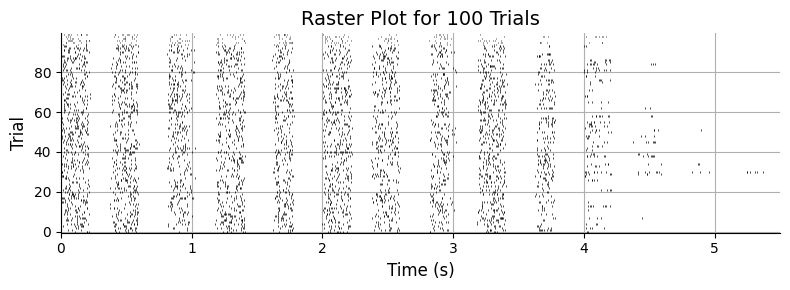

In [7]:
def raster_plot(trial_length, spike_matrix, num_trials=100):
        _, ax = plt.subplots(figsize=(8, 3))
    
        # eventplot expect a list of array, one array per row/trial
        spike_list = []
        for trial in range(num_trials):
            spikes = spike_matrix[:, trial]  # Extract spike times for the current trial
            spikes = spikes[~np.isnan(spikes)] # Remove NaN values
            spike_list.append(spikes)  # Append valid spike times to the list
    
        # Eventplot
        ax.eventplot(spike_list, colors='black', linelengths=0.8, linewidths=0.5)
        ax.set_xlim(0, trial_length)
        ax.set_ylim(-0.5, num_trials - 0.5)
        ax.set_xlabel("Time (s)", fontsize=12)
        ax.set_ylabel("Trial", fontsize=12)
        ax.set_title(f"Raster Plot for {num_trials} Trials", fontsize=14)
        sns.despine()
        plt.grid()
        plt.tight_layout()
        plt.show()

raster_plot(trial_length=T, spike_matrix=spike_data_in_s, num_trials=100)

##### b) ISI
Plot a histogram of the ISIs pooled across trials. Hint: use the numpy function diff. How are the ISIs distributed?

Mean ISI: 0.0830 seconds
Standard Deviation of ISI: 0.1123 seconds


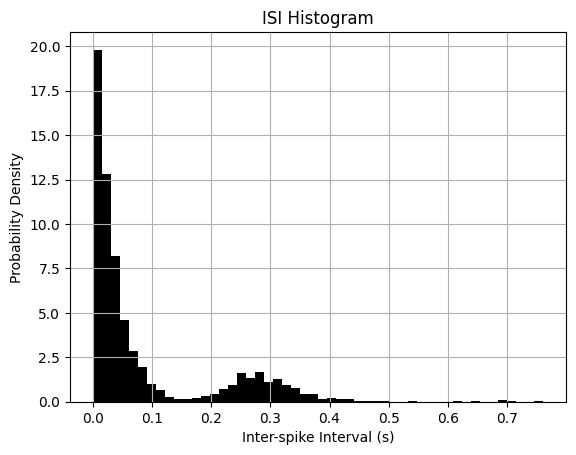

In [13]:
def compute_isis(spike_matrix=spike_data_in_s):
        isis_all = []  # List to store all ISIs from all trials

        # Loop through each trial (column-wise in the matrix)
        for trial_spikes in spike_matrix.T:
            # Remove 'nan' values (non-spike entries in the trial)
            trial_spikes = trial_spikes[~np.isnan(trial_spikes)]

            # Compute ISIs by taking the difference between consecutive spike times
            isis = np.diff(trial_spikes)

            # Add the ISIs of this trial to the overall list
            if len(isis) > 0:
                isis_all.extend(isis)

        # Convert to numpy array before returning
        return np.array(isis_all)

isis_values = compute_isis(spike_matrix=spike_data_in_s)
mean_isi = np.mean(isis_values)
std_isi = np.std(isis_values)
print(f"Mean ISI: {mean_isi:.4f} seconds")
print(f"Standard Deviation of ISI: {std_isi:.4f} seconds")

plt.hist(isis_values, bins=50, density=True, color='black')
plt.xlabel("Inter-spike Interval (s)")
plt.ylabel("Probability Density")
plt.title("ISI Histogram")
plt.grid()
plt.show()

The ISI distribution deviates from what is expected in a homogeneous Poisson process, where ISIs follow a single-peaked exponential distribution. However, in those ISI distribution we see two peaks (even so second is way smaller) suggests that the spiking behavior may not be entirely random. 

##### c) CV 
Compute the coefficient of variation CV from the pooled ISIs

In [14]:
cv = std_isi / mean_isi
print(f"Coefficient of Variation (CV) of ISI: {cv:.4f}")

Coefficient of Variation (CV) of ISI: 1.3538


As CV > 1, suggest bursting behaviour. Consistent with results from ISIs, where many short ISIs  may demonstrate within burst and  long ISIs the between bursts.

##### d) Fano-Factor
 

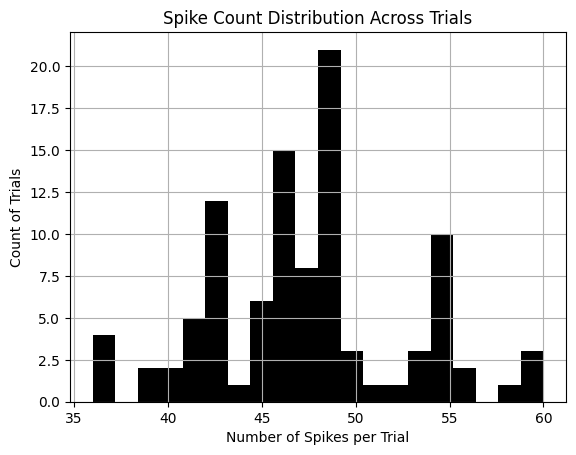

In [16]:
spike_counts = []  # List to store spike counts for each trial
for trial_spikes in spike_data_in_s.T:
    # Remove 'nan' values from the trial
    trial_spikes = trial_spikes[~np.isnan(trial_spikes)]

    # Count spikes in the entire trial and store
    spike_counts.append(len(trial_spikes))

plt.hist(spike_counts, bins=20, color='black')
plt.xlabel("Number of Spikes per Trial")
plt.ylabel("Count of Trials")
plt.title("Spike Count Distribution Across Trials")
plt.grid()
plt.show()

d.2) time-resolved  F in non-overlapping windows of lengths TW ∈ [0.3, 0.5, 1] s.

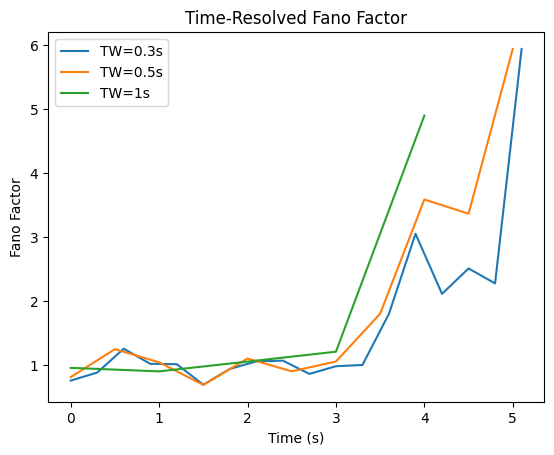

C:\Users\anina\AppData\Local\Temp\ipykernel_21576\2533658163.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fano_trial_sbin, fano_trial_mbin, fano_trial_hbin],


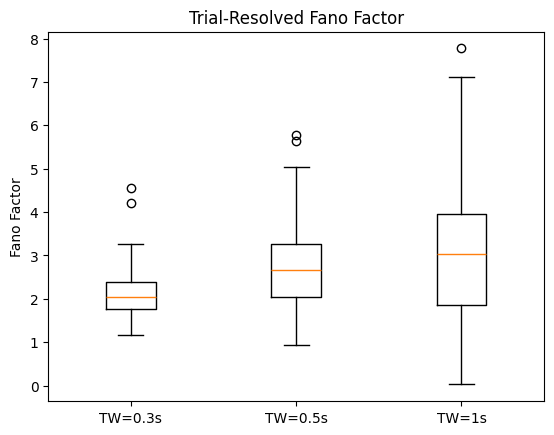

In [34]:
def time_resolved(TW, spike_matrix=spike_data_in_s.T):
    n_bins = int(T / TW)
    spike_counts_per_bin = np.zeros((spike_matrix.shape[0], n_bins))
 
    for trial in range(spike_matrix.shape[0]):
        trial_spikes = spike_matrix[trial, :]  # Extract spike times for the current trial
        trial_spikes = trial_spikes[~np.isnan(trial_spikes)] 
        
        for bin_idx in range(n_bins):
            start_time = bin_idx * TW 
            end_time = (bin_idx + 1) * TW
            spike_counts_per_bin[trial, bin_idx] = np.sum((trial_spikes >= start_time) & (trial_spikes < end_time))

    return spike_counts_per_bin


spike_counts_per_sbin = time_resolved(TW=0.3, spike_matrix=spike_data_in_s.T)
spike_counts_per_mbin = time_resolved(TW=0.5, spike_matrix=spike_data_in_s.T)
spike_counts_per_hbin = time_resolved(TW=1, spike_matrix=spike_data_in_s.T)

#time resolved fano factor for different time windows
fano_factor_per_sbin = np.var(spike_counts_per_sbin, axis=0) / np.mean(spike_counts_per_sbin, axis=0)
fano_factor_per_mbin = np.var(spike_counts_per_mbin, axis=0) / np.mean(spike_counts_per_mbin, axis=0)
fano_factor_per_hbin = np.var(spike_counts_per_hbin, axis=0) / np.mean(spike_counts_per_hbin, axis=0)

# Trial-resolved: var/mean over bins within each trial → shape (n_trials,)
fano_trial_sbin = np.var(spike_counts_per_sbin, axis=1) / np.mean(spike_counts_per_sbin, axis=1)
fano_trial_mbin = np.var(spike_counts_per_mbin, axis=1) / np.mean(spike_counts_per_mbin, axis=1)
fano_trial_hbin = np.var(spike_counts_per_hbin, axis=1) / np.mean(spike_counts_per_hbin, axis=1)

# Plotting the time-resolved Fano Factor for different time windows
plt.plot(np.arange(len(fano_factor_per_sbin)) * 0.3, fano_factor_per_sbin, label='TW=0.3s')
plt.plot(np.arange(len(fano_factor_per_mbin)) * 0.5, fano_factor_per_mbin, label='TW=0.5s')
plt.plot(np.arange(len(fano_factor_per_hbin)) * 1,   fano_factor_per_hbin, label='TW=1s')
plt.xlabel("Time (s)")
plt.ylabel("Fano Factor")
plt.title("Time-Resolved Fano Factor")
plt.legend()
plt.show()


# Plotting the trial-resolved Fano Factor for different time windows
plt.boxplot([fano_trial_sbin, fano_trial_mbin, fano_trial_hbin],
            labels=['TW=0.3s', 'TW=0.5s', 'TW=1s'])
plt.ylabel("Fano Factor")
plt.title("Trial-Resolved Fano Factor")
plt.show()

Calculating time-resolved Fano Facotor (F as function of time), demonstarting an increase of F over time.  This indicates that spike count variability isnt constant (firing statistics change across the trial)  - contradicts a homogeneous Poisson assumption. 

Trial-resolved (fix time window, variability across trials) increase with higher window size, as with larger TW, fewer windows per trial and so noiser variance estimate. Spread of the boxplot also grows with TW because with fewer windows the estimate of F per trial becomes less reliable

In [36]:
variance_spike_counts = np.var(spike_counts)
mean_spike_counts = np.mean(spike_counts)
fano_factor = variance_spike_counts / mean_spike_counts

print(f"Fano Factor for spike counts across trials for Tw = T: {fano_factor:.4f}")

Fano Factor for spike counts across trials for Tw = T: 0.5716


Interesting, for Tw = T F < 1, so more regular than Poison. So across all trials neuron fires at a roughly consistent total rate, or?